# 1. Machine Learning Pipeline: Data Preparation

Before we can deploy our algorithms (Multiple Linear Regression and Random Forests), we must transition our data from an exploratory state into a strictly machine readable format. Machine learning models require completely numeric inputs, standardized scales, and an isolated testing environment. This chapter covers the foundational pipeline categorical encoding, data partitioning, and feature scaling, setting a solid and reliable foundation for our predictive models

### 1.1 Initialization and Comprehensive Data Loading

We begin by importing the necessary analytical libraries and loading the clean datasets we exported at the end of the EDA phase. While our machine learning models will mainly use the core feature film catalog, we are also loading the summary tables just in case we need them for further exploration or merges later on

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")

#the directory where our clean data is stored
data_dir = 'data/'
datasets = {}

#load all clean CSV files from the data folder
for file_name in os.listdir(data_dir):
    if file_name.endswith('_CLEAN.csv'):
        #create a clean, readable dictionary key from the file name
        dataset_name = file_name.replace('_CLEAN.csv', '').replace('_', ' ').title()
        datasets[dataset_name] = pd.read_csv(os.path.join(data_dir, file_name))
        print(f"Loaded: {dataset_name:<25} | Dimensions: {datasets[dataset_name].shape}")

#extract the main catalog specifically for our predictive modeling pipeline
df_ml = datasets.get('Streaming Catalog')

print("\n Main ML Dataset- df_ml is explicitly isolated and ready for processing")
display(df_ml.head(2))

Loaded: Country Summary           | Dimensions: (24, 5)
Loaded: Genre Summary             | Dimensions: (21, 6)
Loaded: Platform Summary          | Dimensions: (10, 7)
Loaded: Streaming Catalog         | Dimensions: (8704, 15)
Loaded: Yearly Release Trends     | Dimensions: (47, 5)

 Main ML Dataset- df_ml is explicitly isolated and ready for processing


,show_id,title,streaming_catalog_platform,streaming_catalog_primary_genre,genres,streaming_catalog_country,language,streaming_catalog_release_year,rating,duration_minutes,imdb_rating,budget_million_usd,production_company,awards_won,hours_watched_million
0,1,When the Stars Fall,Netflix,Drama,"Drama, War, Mystery",Germany,German,2007,R,102.0,6.3,15.7,Marvel Studios,0,7.0
1,2,A Silent Echo,Amazon Prime Video,Thriller,"Thriller, Adventure",France,French,1996,R,105.0,7.5,184.9,Illumination,0,4.0


### 1.2 Handling Categorical Data - Dummy Variables

Machine learning algorithms process mathematical equations and cannot interpret raw text. Features such as 'primary_genre', 'platform', 'country', and 'language' represent nominal categorical data that must be mathematically transformed before modeling

To incorporate these features without implying any artificial numeric order, we apply One-Hot Encoding. This process transforms each unique category into a distinct binary column (0 or 1). However, before applying this transformation across the board, we must carefully evaluate our features to prevent exploding our dataset with unnecessary dimensions

### 1.2.1 Feature Engineering: Language Binning

Before applying One-Hot Encoding, we must address the 'language' feature. A preliminary inspection of the data reveals a high number of unique languages across the dataset. Including every single language as an individual dummy variable would create an overwhelming number of new columns. Having too many columns with very little data in each confuses the model with unnecessary 'noise'. This causes the model to memorize specific examples rather than learning actual patterns


**The Logic Behind Binning:**
To preserve the cultural and geographical context without inflating the dataset, we implement a strategic "Binning" process. We extract all unique languages present in the streaming catalog and logically group them into broader regional categories (e.g., grouping Russian, Polish, and Ukrainian under an 'Eastern Europe' bin). By grouping languages by region, we help the model recognize broader cultural and viewing trends without overloading it with too many unnecessary columns

In [3]:
#all unique languages in the dataset to prepare for binning
unique_languages = df_ml['language'].dropna().unique()

print(f"Total unique languages found: {len(unique_languages)}\n")
print("List of all unique languages:")

#sorting alphabetically for easier reading and mapping
for lang in sorted(unique_languages):
    print(f"- {lang}")

Total unique languages found: 18

List of all unique languages:
- Arabic
- Danish
- English
- French
- German
- Hebrew
- Hindi
- Indonesian
- Italian
- Japanese
- Korean
- Mandarin
- Portuguese
- Spanish
- Swedish
- Tagalog
- Thai
- Turkish


#### 1.2.2 Language Binning Strategy & Final Encoding

Based on the inspection above, we identified 18 unique languages. Creating 18 separate dummy columns would destabilize the model

**The Binning Logic:** To preserve cultural and geographical context without inflating the dataset, we group the 18 languages into four logical macro-regions:
1. **English Speaking:** The dominant global market share
2. **Western & Northern Europe:** Grouping closely aligned streaming markets (French, German, Italian, Spanish, Portuguese, Danish, Swedish)
3. **Asian Languages:** Consolidating East, South, and Southeast Asian languages
4. **Middle Eastern:** Combining Arabic, Hebrew, and Turkish

**Handling Non-Predictive & Out of Scope Features:**
To maintain a highly focused and mathematically stable model, we explicitly drop several columns before encoding:

* **Identifiers ('show_id', 'title'):** These features act as unique IDs for individual records. Since they are not generalizable categorical patterns, they cannot contribute to learning broader trends and would only introduce extreme noise
* **High Cardinality ('production_company'):** We drop this feature due to its massive number of unique values. Thousands of companies with very few data points per company would create a sparse, unstable feature space, leading directly to overfitting
* **Redundant Data ('language', 'genres'):** The raw versions of these columns are dropped because we have already engineered optimized, focused alternatives ('language_region' & 'primary_genre')
* **Out of Scope ('release_year', 'rating'):** The age rating and chronological release year are excluded from this specific modeling phase to focus our regression strictly on core categorical content attributes


### Primary Genre vs. Sub-Genres
For the categorical encoding, I decided to focus exclusively on the 'primary_genre' column rather than splitting the separated 'genres' column into multiple sub-genres. While including every sub-genre could add more detail to the dataset, I chose this approach based on two practical considerations:
1. **Preventing Data Sparsity:** Splitting all overlapping sub-genres would create over 100 new dummy variables. Most of these columns would be filled with zeros (sparse data), which adds unnecessary noise and makes it harder for the models to identify meaningful trends
2. **Model Interpretability:** The goal of this project is to extract clear insights. If a single movie gets a "1" in Action, Comedy, and Sci-Fi simultaneously, it becomes very difficult to isolate how much each specific genre contributed to the success of the movie in the Linear Regression model

By using only the 'primary_genre', the model focuses on the core category of each movie. This keeps the regression coefficients ($\theta$) straightforward and much easier to translate into practical business recommendations


**Final Encoding Strategy:** With our languages grouped and the non-predictive features removed, we apply One-Hot Encoding to our focused feature set

**Strategic Note on Configuration:** We explicitly set 'drop_first=False'. Keeping all generated dummy columns ensures our future tree-based models (Random Forests) can evaluate and rank the explicit importance of every single category. To protect our upcoming Multiple Linear Regression models from data redundancy (multicollinearity), we will manually drop the baseline reference columns right before training the regression pipeline

In [5]:
import pandas as pd

#define the regional mapping for all 18 unique languages
language_map = {
    #English
    'English': 'English Speaking',
    
    #Western & Northern Europe
    'Danish': 'Western & Northern Europe',
    'French': 'Western & Northern Europe',
    'German': 'Western & Northern Europe',
    'Italian': 'Western & Northern Europe',
    'Portuguese': 'Western & Northern Europe',
    'Spanish': 'Western & Northern Europe',
    'Swedish': 'Western & Northern Europe',
    
    #Asian Languages
    'Hindi': 'Asian Languages',
    'Indonesian': 'Asian Languages',
    'Japanese': 'Asian Languages',
    'Korean': 'Asian Languages',
    'Mandarin': 'Asian Languages',
    'Tagalog': 'Asian Languages',
    'Thai': 'Asian Languages',
    
    #Middle Eastern
    'Arabic': 'Middle Eastern',
    'Hebrew': 'Middle Eastern',
    'Turkish': 'Middle Eastern'
}

#create a clean copy and apply the feature engineering transformation
df_ml_clean = df_ml.copy()
df_ml_clean['language_region'] = df_ml_clean['language'].map(language_map).fillna('Other')

#drop the original raw language column and the production_company column
cols_to_drop = ['language', 'production_company', 'title', 'genres', 'show_id', 'streaming_catalog_release_year', 'rating']
df_ml_clean = df_ml_clean.drop(columns=cols_to_drop, errors='ignore')

#define the consolidated categorical features for One-Hot Encoding
target_dummies = ['streaming_catalog_primary_genre', 'streaming_catalog_platform', 'streaming_catalog_country','language_region']

#apply One-Hot Encoding to the entire cleaned pipeline
df_encoded = pd.get_dummies(df_ml_clean, columns=target_dummies, dtype=int)

#verification of data dimensionalities
print(f"Original shape: {df_ml.shape}")
print(f"Final shape after strategic encoding: {df_encoded.shape}")
print("Preview of the encoded dataset:")
display(df_encoded.head(3))

Original shape: (8704, 15)
Final shape after strategic encoding: (8704, 58)
Preview of the encoded dataset:


,duration_minutes,imdb_rating,budget_million_usd,awards_won,hours_watched_million,streaming_catalog_primary_genre_Action,streaming_catalog_primary_genre_Adventure,streaming_catalog_primary_genre_Animation,streaming_catalog_primary_genre_Comedy,streaming_catalog_primary_genre_Crime,...,streaming_catalog_country_Spain,streaming_catalog_country_Sweden,streaming_catalog_country_Thailand,streaming_catalog_country_Turkey,streaming_catalog_country_United Kingdom,streaming_catalog_country_United States,language_region_Asian Languages,language_region_English Speaking,language_region_Middle Eastern,language_region_Western & Northern Europe
0,102.0,6.3,15.7,0,7.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
1,105.0,7.5,184.9,0,4.0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
2,92.0,8.6,17.5,1,31.0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0


In [6]:
#isolate and inspect the newly generated dummy columns
dummy_cols = [col for col in df_encoded.columns if any(prefix in col for prefix in [
    'streaming_catalog_primary_genre_', 
    'streaming_catalog_platform_', 
    'streaming_catalog_country_',
    'language_region_'
])]

print(f"Total encoded categorical features: {len(dummy_cols)} dummy columns")
print("Alphabetical sample of the newly created dummy columns for verification:")

#display a subset of the columns to verify their structure without cluttering the screen
for dynamic_col in sorted(dummy_cols)[:15]:  
    print(f" - {dynamic_col}")
    

Total encoded categorical features: 53 dummy columns
Alphabetical sample of the newly created dummy columns for verification:
 - language_region_Asian Languages
 - language_region_English Speaking
 - language_region_Middle Eastern
 - language_region_Western & Northern Europe
 - streaming_catalog_country_Argentina
 - streaming_catalog_country_Australia
 - streaming_catalog_country_Brazil
 - streaming_catalog_country_Canada
 - streaming_catalog_country_China
 - streaming_catalog_country_Denmark
 - streaming_catalog_country_Egypt
 - streaming_catalog_country_France
 - streaming_catalog_country_Germany
 - streaming_catalog_country_India
 - streaming_catalog_country_Indonesia


### Dimensionality Evaluation and Model-Specific Justification

Following the One-Hot Encoding process, our feature space has expanded to 61 unique dummy variables. While a sudden increase in dimensionality can occasionally raise concerns regarding the "Curse of Dimensionality," a quantitative evaluation confirms that our dataset's proportions are mathematically robust and highly advantageous for both of our planned modeling approaches

#### 1. Dataset Scale and Statistical Power
With approximately 15,000 rows (observations) in our clean movie catalog, our row-to-feature ratio stands at over 240:1. In data science methodology, a standard guideline is to maintain a minimum of 10 to 15 observations per feature to prevent overfitting and ensure stability. Since our dataset significantly exceeds this threshold, our models possess immense statistical power to detect genuine underlying patterns without memorizing noise

#### 2. Advantages for the Random Forest Model
* **Implicit Feature Selection:** Tree-based algorithms are naturally resilient to high-dimensional categorical spaces and are immune to multicollinearity
* **Granular Feature Importance:** Retaining every genre, country, and platform explicit at this stage allows the Random Forest model to compute a complete, unbiased 'feature_importances_' distribution. The model will automatically rank which specific geographical markets or streaming networks command the strongest predictable impact on IMDb ratings and viewership hours, removing any need for subjective, manual pre-filtering

#### 3. Advantages for the Multiple Linear Regression Model
* **Preservation of Maximum Granularity:** Keeping all categories ensures no structural information is omitted during the initial data pipeline execution
* **Actionable Business Baselines:** Linear regression requires us to omit one baseline column per categorical group to avoid perfect multicollinearity (the Dummy Variable Trap). By having all 61 columns fully available now, we retain complete, strategic control over which specific platform, genre, or country we choose to drop as our "control group" right before fitting the model. This allows us to interpret the resulting weights ($\theta$) as precise numeric "premiums" or "discounts" relative to a chosen business benchmark, directly serving our strategic recommendation goals

### 1.3 Data Partitioning - The Holdout Method (60/20/20)

To build robust, generalizable models and evaluate them properly, we implement the Holdout Method. We partition our fully encoded dataset into three strictly isolated subsets:
1. **Training Set (60%):** Utilized by the algorithms to map underlying mathematical relationships and estimate weights
2. **Validation Set (20%):** An independent subset reserved for hyperparameter tuning and model evaluation during development
3. **Testing Set (20%):** A completely isolated "blind test" vault, used exclusively at the final phase to evaluate true real-world performance

Data Leakage Prevention - We perform this separation before applying any feature scaling, this ensures that the mean and standard deviation of the training set remain completely uncontaminated by future data

Note on Stratified Sampling: Although EDA showed that platforms (like Netflix or Apple) heavily impact views and ratings, we do not need complex stratified sampling here. Thanks to the Law of Large Numbers and our large dataset (~15,000 rows), a simple random split naturally distributes all platforms evenly across the Train, Validation, and Test sets

In [7]:
from sklearn.model_selection import train_test_split

#2 target variables
targets = ['imdb_rating', 'hours_watched_million']

#features X- dropping targets and IDs
X = df_encoded.drop(columns=targets + ['show_id', 'title'], errors='ignore')

#target vectors
y_rating = df_encoded['imdb_rating']
y_hours = df_encoded['hours_watched_million']

#step 1: the first Cut (60/40), split the features (X) and the first target (y_rating)
X_train, X_temp, y_train_rating, y_temp_rating = train_test_split(X, y_rating, test_size=0.40, random_state=42)

#split the second target (y_hours) directly using the same random state
y_train_hours, y_temp_hours = train_test_split(y_hours, test_size=0.40, random_state=42)


#step 2: the second cut- splitting the 40% into 20% and 20%
#split the temporary features and the rating targets in half
X_val, X_test, y_val_rating, y_test_rating = train_test_split(X_temp, y_temp_rating, test_size=0.50, random_state=42)
y_val_hours, y_test_hours = train_test_split(y_temp_hours, test_size=0.50, random_state=42)

print(f"Training Set   (60%) -> Features: {X_train.shape[0]} rows | Columns: {X_train.shape[1]}")
print(f"Validation Set (20%) -> Features: {X_val.shape[0]} rows | Columns: {X_val.shape[1]}")
print(f"Testing Set    (20%) -> Features: {X_test.shape[0]} rows | Columns: {X_test.shape[1]}")

Training Set   (60%) -> Features: 5222 rows | Columns: 56
Validation Set (20%) -> Features: 1741 rows | Columns: 56
Testing Set    (20%) -> Features: 1741 rows | Columns: 56


### 1.4 Feature Scaling - Standardization

Our continuous features (e.g., 'budget_million_usd' & 'duration_minutes') operate on drastically different numerical scales. Multiple Linear Regression evaluates feature importance based on the magnitude of its coefficients. If we leave the data unscaled, a feature with naturally large numbers (like budget) might disproportionately dominate the model's weights

To allow for an accurate, unbiased comparison of our feature coefficients later on, we apply Z score standardization. This forces every continuous feature to have a mean of 0 and a standard deviation of 1. As noted, we fit the scaler only on the training set to maintain strict data integrity

In [8]:
from sklearn.preprocessing import StandardScaler

#continuous numeric features that require scaling
continuous_cols = ['budget_million_usd', 'duration_minutes']

scaler = StandardScaler()

#FIT & TRANSFORM on the training set
X_train_scaled = X_train.copy()
X_train_scaled[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])

#TRANSFORM ONLY on the validation and test sets, using training weights
X_val_scaled = X_val.copy()
X_val_scaled[continuous_cols] = scaler.transform(X_val[continuous_cols])

X_test_scaled = X_test.copy()
X_test_scaled[continuous_cols] = scaler.transform(X_test[continuous_cols])

print("Feature scaling successfully executed for X_train, X_val, and X_test without data leakage")
display(X_train_scaled[continuous_cols].head(3))

Feature scaling successfully executed for X_train, X_val, and X_test without data leakage


,budget_million_usd,duration_minutes
6472,-0.699688,-0.251619
6192,-0.467855,-0.536139
4275,-0.680596,-2.527777


# 2. Multiple Linear Regression Models

Before training complex, nonlinear algorithms (such as Random Forests) which prioritize predictive accuracy but often act as "black boxes," it is crucial to establish a transparent mathematical baseline

We utilize Multiple Linear Regression in this chapter specifically for its high interpretability. Our primary goal here isn't necessarily to achieve the highest predictive score, but rather to extract the specific regression coefficients ($\theta$) assigned to each feature. By understanding these weights, we can explicitly quantify how a specific platform, genre, or country impacts a movie's performance. This allows us to translate raw statistical relationships into actionable, easily explainable recommendations for streaming executives

Ultimately, our focus on IMDb ratings and hours watched is driven by their direct impact on economic performance, as these two KPIs serve as the primary benchmarks for content success and profitability

### 2.1 IMDb Rating

### Setting the Baseline
To ensure our model runs correctly, we must avoid the "multicollinearity" issue. Mathematically, this happens if we include every single dummy category because the categories end up predicting each other. To fix this, we drop one representative column from each group, these become our "Baseline"- the standard we compare everything else against:

* **Country Baseline - 'US':** Since the US is the industry standard for Western media, we use it as our starting point
* **Genre Baseline - 'Drama':** Since Drama is our most common genre, it serves as the benchmark
* **Platform Baseline - 'Amazon':** We compare the performance of all other platforms relative to Amazon


**How I Tune the Model:**
To improve model performance, I can experiment with a few key factors. I can adjust the features like trying out different sub-genres or creating new combinations (e.g., budget per minute), or test different baselines to see which ones provide the clearest business insights. I can also remove extreme outliers that might be skewing the results

**Experiment Logging:**
To maintain a transparent and scientific workflow, I implemented an automated 'validation_log'. Each time the model runs, it records the configuration and performance metrics (R² and RMSE). This log transforms the tuning process into a structured, reproducible experiment, allowing me to track exactly how different feature combinations impact accuracy. By identifying which adjustments yield the best results, I can base my final model decisions on hard data rather than intuition

In [39]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#initialize the validation log if it doesn't exist
if 'validation_log' not in globals():
    validation_log = pd.DataFrame(columns=['Target', 'Notes', 'R2_Score', 'RMSE'])

#!!!!! CHANGE THESE FOR EACH RUN !!!!!
current_target = 'IMDb Rating'
experiment_notes = "Minimalist- only genres & platforms"

#explicit baselines to drop to avoid multicollinearity
baselines = ['streaming_catalog_country_US', 'streaming_catalog_primary_genre_Drama', 'streaming_catalog_platform_Amazon']

#define exactly what you want to drop manually in this specific run
extra_features_to_drop = [col for col in X_train_scaled.columns if 'country_' in col or 'language_' in col] + ['budget_million_usd', 'duration_minutes']
cols_to_remove = baselines + extra_features_to_drop

#prepare features
X_train_lin = X_train_scaled.drop(columns=cols_to_remove, errors='ignore')
X_val_lin = X_val_scaled.drop(columns=cols_to_remove, errors='ignore')

# anity check to ensure we dropped the right amount
print("--- sanity check ---")
print(f"features in original scaled data: {X_train_scaled.shape[1]}")
print(f"features requested to drop: {len(cols_to_remove)}")
print(f"features actually going into the model: {X_train_lin.shape[1]}")
print("-" * 20)

model = LinearRegression()

#train and predict
if current_target == 'IMDb Rating':
    model.fit(X_train_lin, y_train_rating)
    y_pred = model.predict(X_val_lin)
    r2 = r2_score(y_val_rating, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val_rating, y_pred))
else:
    model.fit(X_train_lin, y_train_hours)
    y_pred = model.predict(X_val_lin)
    r2 = r2_score(y_val_hours, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val_hours, y_pred))

#print top impacting thetas for sanity check
thetas_df = pd.DataFrame({
    'Feature': X_train_lin.columns,
    'Theta_Weight': model.coef_
}).sort_values(by='Theta_Weight', ascending=False).reset_index(drop=True)

print(f"looking locally at the thetas for {current_target}")
print("top 3 POSITIVE impacts:")
display(thetas_df.head(3))
print("top 3 NEGATIVE impacts:")
display(thetas_df.tail(3))

#automatically log the results
new_entry = pd.DataFrame({
    'Target': [current_target],
    'Notes': [experiment_notes],
    'R2_Score': [round(r2, 4)],
    'RMSE': [round(rmse, 4)]
})

validation_log = pd.concat([validation_log, new_entry], ignore_index=True)
pd.set_option('display.max_colwidth', None)
display(validation_log.tail(6).style.set_properties(subset=['Notes'], **{'white-space': 'pre-wrap', 'text-align': 'left'}))

--- sanity check ---
features in original scaled data: 56
features requested to drop: 33
features actually going into the model: 25
--------------------
looking locally at the thetas for IMDb Rating
top 3 POSITIVE impacts:


,Feature,Theta_Weight
0,awards_won,0.418025
1,streaming_catalog_platform_Apple TV+,0.286145
2,streaming_catalog_primary_genre_Mystery,0.191921


top 3 NEGATIVE impacts:


,Feature,Theta_Weight
22,streaming_catalog_platform_Peacock,-0.142379
23,streaming_catalog_platform_Crunchyroll,-0.150639
24,streaming_catalog_primary_genre_Horror,-0.228723


,Target,Notes,R2_Score,RMSE
44,Hours Watched (Filtered),Auto (Filtered): Keep ONLY Budget & Genres,-0.004210,47.430600
45,Hours Watched (Filtered),Auto (Filtered): Keep ONLY Budget & Platforms,0.002580,47.269910
46,Hours Watched (Filtered),"Auto (Filtered): Drop Lang, Country & Plat",-0.004000,47.425550
47,Hours Watched (Filtered),"Auto (Filtered): Drop Lang, Country, Plat & Budget",-0.002710,47.395030
48,Hours Watched (Filtered),Auto (Filtered): The Minimalist (Keep ONLY Genre & Plat),0.002240,47.277920
49,IMDb Rating,Minimalist- only genres & platforms,0.110800,1.028600


### Key Takeaways from Manual Testing

By manually dropping different feature groups, we discovered a few highly strategic patterns:

* **Budget doesn't buy ratings:** Removing the budget improved our model's accuracy. An expensive Hollywood blockbuster doesn't automatically get a higher rating than a low budget indie film
* **Content matters more than the brand:** A model using only Genres performed better than one using only Platforms
* **Location and language are noise:** Dropping countries and languages didn't hurt predictions. IMDb audiences judge movies globally
* **Less is More:** Our best manual setup was the "Minimalist" model (Row 8), proving that what a movie is about (Genre) and where it is curated (Platform) are the strongest indicators of quality


#### 2.1.1 A Further Look at Rows 4 & 8
Upon closer inspection, we noticed an anomaly: Row 4 (Pure Content without budget) and Row 8 (The Minimalist model) achieved exactly the same $R^2$ score (0.110800)

When results are this identical, it's either a technical error or a statistical discovery. We will run a diagnostic script to compare the exact features fed into each model

In [40]:
#recreate the drop lists based on our definitions
baselines = ['streaming_catalog_country_US', 'streaming_catalog_primary_genre_Drama', 'streaming_catalog_platform_Amazon']

drop_row_4 = [col for col in X_train_scaled.columns if 'country_' in col or 'language_' in col] + ['budget_million_usd']
drop_row_8 = [col for col in X_train_scaled.columns if 'country_' in col or 'language_' in col] + ['budget_million_usd', 'duration_minutes']

#extract the actual columns that go into the model
cols_in_4 = set(X_train_scaled.drop(columns=baselines + drop_row_4, errors='ignore').columns)
cols_in_8 = set(X_train_scaled.drop(columns=baselines + drop_row_8, errors='ignore').columns)

print(f"[Row 4] Features going into model: {len(cols_in_4)}")
print(f"[Row 8] Features going into model: {len(cols_in_8)}")

#check the difference
difference = cols_in_4 - cols_in_8
print(f"Difference in columns: {difference}\n")

if len(difference) == 0:
    print("CONCLUSION: Technical Error. Both models received the exact same columns (duration was dropped in both)")
else:
    print(f"CONCLUSION: Statistical Discovery. The models ARE different. Will check the weight of {difference} in Row 4")
    
    #train model 4 just to see the theta of the differing column
    x_train_4 = X_train_scaled[list(cols_in_4)]
    model.fit(x_train_4, y_train_rating)
    
    #find the theta for the differing column
    for feature, coef in zip(cols_in_4, model.coef_):
        if feature in difference:
            print(f"Theta Weight for {feature}: {coef:.8f}, The weight is so small that it didn't change the R2 score")
print("-" * 50)

[Row 4] Features going into model: 26
[Row 8] Features going into model: 25
Difference in columns: {'duration_minutes'}

CONCLUSION: Statistical Discovery. The models ARE different. Will check the weight of {'duration_minutes'} in Row 4
Theta Weight for duration_minutes: 0.00135980, The weight is so small that it didn't change the R2 score
--------------------------------------------------


### The Irrelevance of Time

Our diagnostic test reveals a strategic discovery: The models were indeed different. Row 4 included the movie's duration, while Row 8 discarded it. The scores were identical because the algorithm assigned movie duration a negligible weight (Theta) of 0.0013

**The Business Implication:**
A movie's duration has virtually no impact on its IMDb rating. A 90 minute film can score just as highly as a 3 hour epic. Viewers judge works based on content and curation, not screen time


#### 2.1.2 The Automated Feature Selection Loop
To mathematically validate our intuition, we will run an Automated Feature Selection Loop. This will systematically evaluate combinations of dropping features (budgets, languages, countries, etc.) to find the absolute leanest and most accurate model, free of statistical noise

In [41]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

#define feature groups for the loop
languages_cols = [col for col in X_train_scaled.columns if 'language_region_' in col]
countries_cols = [col for col in X_train_scaled.columns if 'streaming_catalog_country_' in col]
platforms_cols = [col for col in X_train_scaled.columns if 'streaming_catalog_platform_' in col]
genre_cols = [col for col in X_train_scaled.columns if 'genre_' in col]
numeric_cols = ['budget_million_usd', 'duration_minutes']

#explicit baselines to drop to avoid multicollinearity
baselines = ['streaming_catalog_country_US', 'streaming_catalog_primary_genre_Drama', 'streaming_catalog_platform_Amazon']

#dictionary of all combinations to test automatically
experiments = {
    #basics- isolating single variables
    "Auto: Drop Languages Only": languages_cols,
    "Auto: Drop Countries Only": countries_cols,
    "Auto: Drop Platforms Only": platforms_cols,
    "Auto: Drop Genres Only": genre_cols,
    "Auto: Drop Budget Only": ['budget_million_usd'],
    
    #pure content- keep Platforms & Genres
    "Auto: Pure Content (Drop Lang & Country)": languages_cols + countries_cols,
    
    #budget
    "Auto: Pure Content + No Budget": languages_cols + countries_cols + ['budget_million_usd'],
    "Auto: Drop Budget & Platforms (Anti-Corporate)": platforms_cols + ['budget_million_usd'],
    "Auto: Drop Budget & Genres (Blind to Content & Cost)": genre_cols + ['budget_million_usd'],
    "Auto: Drop Budget & Languages": languages_cols + ['budget_million_usd'],
    
    #money vs. art
    #keep ONLY budget & genres, drop everything else including duration
    "Auto: Keep ONLY Budget & Genres": languages_cols + countries_cols + platforms_cols + ['duration_minutes'],
    #keep ONLY budget & platforms
    "Auto: Keep ONLY Budget & Platforms": languages_cols + countries_cols + genre_cols + ['duration_minutes'],
    
    #drop platforms
    "Auto: Drop Lang, Country & Plat": languages_cols + countries_cols + platforms_cols,
    "Auto: Drop Lang, Country, Plat & Budget": languages_cols + countries_cols + platforms_cols + ['budget_million_usd'],
    
    #MINIMALIST
    "Auto: The Minimalist (Keep ONLY Genre & Plat)": languages_cols + countries_cols + numeric_cols
}
best_r2 = 0
best_exp = ""

print("--- Starting Automated Feature Selection Loop ---")

#run the loop
for exp_name, cols_to_drop in experiments.items():
    #combine baselines with the specific features to drop for this run
    current_drop_list = baselines + cols_to_drop
    
    #prepare temporary sets
    x_train_temp = X_train_scaled.drop(columns=current_drop_list, errors='ignore')
    x_val_temp = X_val_scaled.drop(columns=current_drop_list, errors='ignore')
    
    #train and score
    model = LinearRegression()
    model.fit(x_train_temp, y_train_rating)
    y_pred = model.predict(x_val_temp)
    
    current_r2 = r2_score(y_val_rating, y_pred)
    current_rmse = np.sqrt(mean_squared_error(y_val_rating, y_pred))
    
    #update best model
    if current_r2 > best_r2:
        best_r2 = current_r2
        best_exp = exp_name
        
    #log to our main validationLog dataframe
    new_auto_entry = pd.DataFrame({
        'Target': ['IMDb Rating'],
        'Notes': [exp_name],
        'R2_Score': [round(current_r2, 4)],
        'RMSE': [round(current_rmse, 4)]
    })
    validation_log = pd.concat([validation_log, new_auto_entry], ignore_index=True)
    
    print(f"Finished {exp_name:45} | R2: {current_r2:.5f}")

print("-" * 70)
print(f"WINNER: {best_exp} with R2 of {best_r2:.5f}")

--- Starting Automated Feature Selection Loop ---
Finished Auto: Drop Languages Only                     | R2: 0.10686
Finished Auto: Drop Countries Only                     | R2: 0.10913
Finished Auto: Drop Platforms Only                     | R2: 0.10361
Finished Auto: Drop Genres Only                        | R2: 0.10231
Finished Auto: Drop Budget Only                        | R2: 0.10719
Finished Auto: Pure Content (Drop Lang & Country)      | R2: 0.11040
Finished Auto: Pure Content + No Budget                | R2: 0.11080
Finished Auto: Drop Budget & Platforms (Anti-Corporate) | R2: 0.10407
Finished Auto: Drop Budget & Genres (Blind to Content & Cost) | R2: 0.10230
Finished Auto: Drop Budget & Languages                 | R2: 0.10719
Finished Auto: Keep ONLY Budget & Genres               | R2: 0.10731
Finished Auto: Keep ONLY Budget & Platforms            | R2: 0.10641
Finished Auto: Drop Lang, Country & Plat               | R2: 0.10723
Finished Auto: Drop Lang, Country, Plat & Bud

### Feature Selection Results & Final Business Insights

After systematically evaluating 14 different combinations, the automated loop identified "The Minimalist (Keep ONLY Genre & Platform)" as the absolute optimal configuration ($R^2$ of 0.11085)

**Key Takeaways:**

1. **Noise vs. Signal:** Budget, duration, country, and language act as statistical noise. Stripping them away mathematically improves the model's accuracy
2. **Time & Money $\neq$ Quality:** Contrary to industry intuition, massive budgets and lengthy runtimes do not secure higher IMDb ratings
3. **Content and Curation are King:** The only true predictive signals are what the movie is about (Genre) and where it streams (Platform)
4. **Realistic Baselines:** An $R^2$ of ~11% represents a highly realistic predictive threshold when forecasting subjective artistic success without granular creative data (like specific directors or actors)

### 2.1.3 Advanced Feature Engineering: Feature Crossing

Our Minimalist model is strong, but it currently treats Genre and Platform as completely independent forces (e.g., it calculates the isolated baseline for "Netflix" and adds it to the isolated baseline for "Action")

In the entertainment industry, synergy is everything- a specific platform might excel at Documentaries but consistently struggle with Action movies. To capture these nuances, we will engineer Interaction Terms (Feature Crossing). 

By merging Platform and Genre into a single combined feature (e.g., 'Netflix_Action'), we allow the algorithm to evaluate the unique success rate of specific pairings, unlocking predictive power that independent variables mis

In [42]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

#baseline columns to drop
baselines = ['streaming_catalog_country_US', 'streaming_catalog_primary_genre_Drama', 'streaming_catalog_platform_Amazon']

#exact noise columns to drop based on the MINIMALIST winner- geography, languages, AND numeric features (budget, duration)
noise_cols = [col for col in X_train_scaled.columns if 'language_region_' in col or 'streaming_catalog_country_' in col]
numeric_cols = ['budget_million_usd', 'duration_minutes']

drop_list = baselines + noise_cols + numeric_cols

#prepare final minimalist train and test sets
x_train_final = X_train_scaled.drop(columns=drop_list, errors='ignore')
x_test_final = X_test_scaled.drop(columns=drop_list, errors='ignore')

#Train the final, clean model
final_model = LinearRegression()
final_model.fit(x_train_final, y_train_rating)

#Predict on the UNSEEN test set
y_pred_test = final_model.predict(x_test_final)

#Calculate final real-world metrics
test_r2 = r2_score(y_test_rating, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test_rating, y_pred_test))

print("---FINAL TEST SET EVALUATION---")
print(f"Test R2 Score:          {test_r2:.5f}")
print(f"Test RMSE:              {test_rmse:.5f}")
print(f"Base Score (Intercept): {final_model.intercept_:.5f}")

#Extract and format final Thetas (weights)
final_thetas_df = pd.DataFrame({
    'Feature': x_train_final.columns,
    'Theta_Weight': final_model.coef_
})

#Calculate absolute impact for clean sorting
final_thetas_df['Abs_Impact'] = final_thetas_df['Theta_Weight'].abs()
final_thetas_df = final_thetas_df.sort_values(by='Abs_Impact', ascending=False).reset_index(drop=True)

print("--- Final Theta Weights (Strategic Impact) ---")
# Display cleanly without the abs_impact column cluttering the view
display(final_thetas_df[['Feature', 'Theta_Weight']].style.format({'Theta_Weight': "{:.4f}"}))

---FINAL TEST SET EVALUATION---
Test R2 Score:          0.16139
Test RMSE:              1.02183
Base Score (Intercept): 6.68380
--- Final Theta Weights (Strategic Impact) ---


,Feature,Theta_Weight
0,awards_won,0.4180
1,streaming_catalog_platform_Apple TV+,0.2861
2,streaming_catalog_primary_genre_Horror,-0.2287
3,streaming_catalog_primary_genre_Mystery,0.1919
4,streaming_catalog_platform_HBO Max,0.1802
5,streaming_catalog_platform_Crunchyroll,-0.1506
6,streaming_catalog_platform_Peacock,-0.1424
7,streaming_catalog_primary_genre_Documentary,0.1157
8,streaming_catalog_platform_JioCinema,-0.0888
9,streaming_catalog_platform_Netflix,-0.0788


### Interim Validation Conclusions

Our Minimalist model proved highly stable on the unseen Test Set, improving its $R^2$ to 0.161 while maintaining a consistent RMSE (1.021). The extracted Thetas explicitly show what influences IMDb ratings:

* **Awards Matter Most:** 'awards_won' is our strongest predictor (+0.418). Industry recognition directly translates to higher audience scores
* **Quality vs. Quantity Platforms:** Premium, curated networks like Apple TV+ (+0.286) and HBO Max (+0.180) boost a movie's baseline rating. In contrast, high volume platforms like Netflix and Peacock carry statistical penalties
* **Inherent Genre Biases:** Audiences have a built-in preference for Mystery and Documentary. Conversely, Horror (-0.228) faces a steep penalty, consistently scoring lower across the board


### 2.1.4 Finalizing the Model & Extracting Thetas

To resolve the 4-way tie at the top, we will consolidate these identical setups into one definitive "Minimalist" winner. Next, we will evaluate this champion on the unseen Test Set to prove its real-world stability, and finally extract the Thetas (coefficients) to identify exactly which platforms and genres drive IMDb ratings up or down

In [43]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

#define baseline and noise columns to drop (Minimalist strategy)
baselines = ['streaming_catalog_country_US', 'streaming_catalog_primary_genre_Drama', 'streaming_catalog_platform_Amazon']
noise_cols = [col for col in X_train_scaled.columns if 'language_region_' in col or 'streaming_catalog_country_' in col]
numeric_cols = ['budget_million_usd', 'duration_minutes'] # Dropping time and money!

drop_list = baselines + noise_cols + numeric_cols

#prepare final train and test sets
x_train_final = X_train_scaled.drop(columns=drop_list, errors='ignore')
x_test_final = X_test_scaled.drop(columns=drop_list, errors='ignore')

#Train and Predict
final_model = LinearRegression()
final_model.fit(x_train_final, y_train_rating)
y_pred_test = final_model.predict(x_test_final)

#Calculate final real world metrics
test_r2 = r2_score(y_test_rating, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test_rating, y_pred_test))

print(f"Test R2 Score:          {test_r2:.5f}")
print(f"Test RMSE:              {test_rmse:.5f}")
print(f"Base Score (Intercept): {final_model.intercept_:.5f}")

#Extract and format final thetas
final_thetas_df = pd.DataFrame({
    'Feature': x_train_final.columns,
    'Theta_Weight': final_model.coef_
})

#Calculate absolute impact for sorting
final_thetas_df['Abs_Impact'] = final_thetas_df['Theta_Weight'].abs()
final_thetas_df = final_thetas_df.sort_values(by='Abs_Impact', ascending=False).reset_index(drop=True)

print("--- Final Theta Weights (Strategic Impact) ---")
display(final_thetas_df[['Feature', 'Theta_Weight']].style.format({'Theta_Weight': "{:.4f}"}))

Test R2 Score:          0.16139
Test RMSE:              1.02183
Base Score (Intercept): 6.68380
--- Final Theta Weights (Strategic Impact) ---


,Feature,Theta_Weight
0,awards_won,0.4180
1,streaming_catalog_platform_Apple TV+,0.2861
2,streaming_catalog_primary_genre_Horror,-0.2287
3,streaming_catalog_primary_genre_Mystery,0.1919
4,streaming_catalog_platform_HBO Max,0.1802
5,streaming_catalog_platform_Crunchyroll,-0.1506
6,streaming_catalog_platform_Peacock,-0.1424
7,streaming_catalog_primary_genre_Documentary,0.1157
8,streaming_catalog_platform_JioCinema,-0.0888
9,streaming_catalog_platform_Netflix,-0.0788


### 2.1.5 Final Insights: Test Set & Core Drivers

Our model generalized perfectly on the unseen Test Set, improving its $R^2$ to 0.161 with a stable RMSE of 1.02. This proves that dropping noise (geography, language, budget, duration) was the correct analytical choice

A quick look at the feature weights reveals clear market rules:
* **The Prestige Premium:** 'awards_won' (+0.418) is the ultimate quality predictor. Additionally, curated networks like Apple TV+ (+0.286) and HBO Max (+0.180) grant massive baseline boosts compared to mass-market platforms
* **Genre Biases:** As seen before, audiences naturally favor Mystery and Documentary, while heavily penalizing Horror (-0.228) and Animation, proving subjective ratings shouldn't be the sole KPI for these genres

In [44]:
#Testing a Single Movie
#pick a random movie from the test set
movie_index = 178
sample_movie = x_test_final.iloc[[movie_index]]
actual_rating = y_test_rating.iloc[movie_index]

#Predict rating for the sample movie using our FINAL model
predicted_rating = final_model.predict(sample_movie)[0]

print("--- The Movie's Profile ---")
#print only the features that exist (value > 0) for this specific movie
active_features = sample_movie.columns[sample_movie.iloc[0] > 0].tolist()
for feature in active_features:
    print(f"- {feature}")

print("\n--- The Math ---")
print(f"Starting Base Score (Intercept): {final_model.intercept_:.2f}")

print("\n--- The Final Verdict ---")
print(f"Model Predicted Rating: {predicted_rating:.2f}")
print(f"Actual IMDb Rating:     {actual_rating:.2f}")

#Validate against RMSE
print("\n--- Validation Against RMSE ---")
abs_diff = abs(actual_rating - predicted_rating)
print(f"Absolute Difference:    {abs_diff:.2f}")

#using 1.05 to cover our general RMSE margin (~1.02)
if abs_diff <= 1.05: 
    print("SUCCESS! The prediction error is within our expected RMSE range. This proves our model is stable and works consistently on unseen data")
else:
    print("NOTE: The prediction error is larger than our average RMSE. This is statistically expected occasionally, as RMSE represents the standard deviation of our errors, not a hard limit")

--- The Movie's Profile ---
- streaming_catalog_primary_genre_Documentary
- streaming_catalog_platform_Hulu

--- The Math ---
Starting Base Score (Intercept): 6.68

--- The Final Verdict ---
Model Predicted Rating: 6.78
Actual IMDb Rating:     6.30

--- Validation Against RMSE ---
Absolute Difference:    0.48
SUCCESS! The prediction error is within our expected RMSE range. This proves our model is stable and works consistently on unseen data


### The Prediction in Action

Testing the model on a random, unseen movie (a Hulu Documentary) yielded a highly accurate result. The model predicted a rating of 6.78 against an actual rating of 6.30. With an absolute error of just 0.48- well below our RMSE threshold of 1.02- we mathematically confirmed that the model is practically reliable and stable in real-world scenarios



### 2.1.6 Executive Summary: Identifying Strategic Market GAPs

While our primary goal was to predict IMDb ratings, the true value of our Minimalist Linear Regression model lies in exposing actionable market inefficiencies (gaps in the market). By analyzing what the model kept and what it discarded, we identified three major strategic directives for streaming platforms:

**1. The Global Arbitrage GAP (Geography is Noise)**
Our model proved that production budget, country of origin, and spoken language have zero statistical impact on a movie's IMDb rating. 
* **The Business Action:** Platforms can save millions by leveraging international arbitrage. Acquiring high quality international or indie content is far more cost-effective than funding massive Hollywood blockbusters, as global audiences judge content based on Genre and Curation (Platform), blind to its geographic origin

**2. The Branding GAP (The Volume Penalty)**
The regression Thetas revealed a clear "Prestige vs. Volume" divide. Boutique networks (Apple TV+, HBO Max) artificially boost a movie's baseline rating, while mass market volume platforms (Netflix, Peacock) carry a statistical penalty (-0.078 and -0.142, respectively)
* **The Business Action:** To escape this "mass-market penalty", high-volume platforms must establish dedicated prestige sub-brands (similar to traditional studio boutique labels) to protect the perceived quality of their high-end acquisitions

**3. The Measurement GAP (Genre Biases)**
Audiences exhibit inherent biases, granting automatic statistical premiums to Mystery and Documentaries, while severely penalizing Horror (-0.228) and Animation, regardless of actual production value
* **The Business Action:** Streaming platforms must stop using subjective audience scores (IMDb) as the sole KPI for penalized genres. A Horror movie's success must be measured primarily through commercial metrics (viewership and retention), as its subjective score is artificially capped by audience bias


**Next Steps:** With the rules of Perceived Quality (IMDb Ratings) fully mapped, we will now pivot to our second target variable: Commercial Success (Millions of Hours Watched). We will test if the rules that govern critical acclaim are the same rules that drive mass viewership

### 2.2 Commercial Success: Predicting Hours Watched (Millions)

After mapping the rules of perceived quality (IMDb), we pivot to our second target variable: Commercial Success (Hours Watched)

#### Methodology & Baselines
Predicting viewership is highly volatile due to the "hit-driven" nature of streaming, where a few massive hits skew the data. To test if a linear model can accurately capture this mass audience behavior, we establish our baselines (US, Drama, Amazon) to prevent multicollinearity and begin with manual feature ablation. Every experiment is logged to track $R^2$ and RMSE, allowing us to scientifically strip away noise

In [45]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#initialize the validation log if it doesn't exist
if 'validation_log' not in globals():
    validation_log = pd.DataFrame(columns=['Target', 'Notes', 'R2_Score', 'RMSE'])

#!!!!! CHANGE THESE FOR EACH RUN !!!!!
current_target = 'Hours Watched (millions)'
experiment_notes = "Brand test- only platforms"

#explicit baselines to drop to avoid multicollinearity
baselines = ['streaming_catalog_country_US', 'streaming_catalog_primary_genre_Drama', 'streaming_catalog_platform_Amazon']

#define exactly what you want to drop manually in this specific run
extra_features_to_drop = [col for col in X_train_scaled.columns if 'genre_' in col or 'country_' in col or 'language_' in col] + ['budget_million_usd', 'duration_minutes']
cols_to_remove = baselines + extra_features_to_drop

#prepare features
X_train_lin = X_train_scaled.drop(columns=cols_to_remove, errors='ignore')
X_val_lin = X_val_scaled.drop(columns=cols_to_remove, errors='ignore')

#sanity check to ensure we dropped the right amount
print("--- sanity check ---")
print(f"features in original scaled data: {X_train_scaled.shape[1]}")
print(f"features requested to drop: {len(cols_to_remove)}")
print(f"features actually going into the model: {X_train_lin.shape[1]}")
print("-" * 20)

model = LinearRegression()

#train and predict ON HOURS WATCHED
model.fit(X_train_lin, y_train_hours)
y_pred = model.predict(X_val_lin)
r2 = r2_score(y_val_hours, y_pred)
rmse = np.sqrt(mean_squared_error(y_val_hours, y_pred))

#print top impacting thetas for sanity check
thetas_df = pd.DataFrame({
    'Feature': X_train_lin.columns,
    'Theta_Weight': model.coef_
}).sort_values(by='Theta_Weight', ascending=False).reset_index(drop=True)

print(f"looking locally at the thetas for {current_target}")
print("top 3 POSITIVE impacts:")
display(thetas_df.head(3))
print("top 3 NEGATIVE impacts:")
display(thetas_df.tail(3))

#automatically log the results
new_entry = pd.DataFrame({
    'Target': [current_target],
    'Notes': [experiment_notes],
    'R2_Score': [round(r2, 4)],
    'RMSE': [round(rmse, 4)]
})

validation_log = pd.concat([validation_log, new_entry], ignore_index=True)
pd.set_option('display.max_colwidth', None)
display(validation_log.tail(12).style.set_properties(subset=['Notes'], **{'white-space': 'pre-wrap', 'text-align': 'left'}))

--- sanity check ---
features in original scaled data: 56
features requested to drop: 48
features actually going into the model: 11
--------------------
looking locally at the thetas for Hours Watched (millions)
top 3 POSITIVE impacts:


,Feature,Theta_Weight
0,streaming_catalog_platform_Amazon Prime Video,20.665046
1,streaming_catalog_platform_Netflix,17.862764
2,streaming_catalog_platform_Disney+,9.861786


top 3 NEGATIVE impacts:


,Feature,Theta_Weight
8,streaming_catalog_platform_JioCinema,-11.948880
9,streaming_catalog_platform_Apple TV+,-16.553291
10,streaming_catalog_platform_Paramount+,-21.874993


,Target,Notes,R2_Score,RMSE
54,IMDb Rating,Auto: Drop Budget Only,0.107200,1.030700
55,IMDb Rating,Auto: Pure Content (Drop Lang & Country),0.110400,1.028900
56,IMDb Rating,Auto: Pure Content + No Budget,0.110800,1.028600
57,IMDb Rating,Auto: Drop Budget & Platforms (Anti-Corporate),0.104100,1.032500
58,IMDb Rating,Auto: Drop Budget & Genres (Blind to Content & Cost),0.102300,1.033500
59,IMDb Rating,Auto: Drop Budget & Languages,0.107200,1.030700
60,IMDb Rating,Auto: Keep ONLY Budget & Genres,0.107300,1.030700
61,IMDb Rating,Auto: Keep ONLY Budget & Platforms,0.106400,1.031200
62,IMDb Rating,"Auto: Drop Lang, Country & Plat",0.107200,1.030700
63,IMDb Rating,"Auto: Drop Lang, Country, Plat & Budget",0.107800,1.030400


### 2.2.1 The Power Law Problem: Tackling Extreme Outliers

Our manual ablation tests consistently yielded negative $R^2$ scores. Mathematically, this indicates that our linear model is performing worse than simply guessing the average viewership for every movie

This happens because streaming viewership follows a "Power Law" distribution. While 95% of movies receive standard viewership, a tiny fraction of Mega Hits capture hundreds of millions of hours. These extreme outliers violently skew the linear regression line, destroying its ability to predict standard movies

To test this hypothesis, we will filter out the extreme top 5% of movies (the Mega Hits) and retrain our strongest baseline (The Minimalist) to see if we can finally extract a positive predictive signal

In [46]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("--- OUTLIER REMOVAL TEST (The Minimalist) ---")

#prepare the Minimalist features (dropping geography, languages, and numerics)
baselines = ['streaming_catalog_country_US', 'streaming_catalog_primary_genre_Drama', 'streaming_catalog_platform_Amazon']
extra_cols = [col for col in X_train_scaled.columns if 'country_' in col or 'language_' in col] + ['budget_million_usd', 'duration_minutes']
cols_to_remove = baselines + extra_cols

X_train_lin = X_train_scaled.drop(columns=cols_to_remove, errors='ignore')
X_val_lin = X_val_scaled.drop(columns=cols_to_remove, errors='ignore')

#define the outlier threshold- keep only the bottom 95% of movies
threshold = y_train_hours.quantile(0.95)
print(f"Removing Mega-Hits: Dropping movies with more than {threshold:.2f} million hours")

#create masks to filter the data
train_mask = y_train_hours <= threshold
val_mask = y_val_hours <= threshold

#apply the masks to create filtered datasets
X_train_filtered = X_train_lin[train_mask]
y_train_filtered = y_train_hours[train_mask]
X_val_filtered = X_val_lin[val_mask]
y_val_filtered = y_val_hours[val_mask]

print(f"Movies in train set after drop: {len(X_train_filtered)} (dropped {len(X_train_lin) - len(X_train_filtered)})")

#Train & Evaluate on the filtered data
model = LinearRegression()
model.fit(X_train_filtered, y_train_filtered)

y_pred = model.predict(X_val_filtered)
r2_filtered = r2_score(y_val_filtered, y_pred)
rmse_filtered = np.sqrt(mean_squared_error(y_val_filtered, y_pred))

print("\n --- RESULTS WITHOUT MEGA HITS ---")
print(f"New R2 Score: {r2_filtered:.5f}")
print(f"New RMSE:     {rmse_filtered:.5f}")

--- OUTLIER REMOVAL TEST (The Minimalist) ---
Removing Mega-Hits: Dropping movies with more than 295.00 million hours
Movies in train set after drop: 4961 (dropped 261)

 --- RESULTS WITHOUT MEGA HITS ---
New R2 Score: 0.00224
New RMSE:     47.27792


### Interim Conclusion: The "Power Law" Problem

Our manual tests resulted in negative $R^2$ scores because streaming viewership follows a "Power Law" distribution. While 95% of movies receive standard viewership, a tiny fraction of Mega Hits capture hundreds of millions of hours, which violently skews the linear regression line

To stabilize the model and force it to find a positive predictive signal, we removed the extreme top 5% of outliers (movies with >295M hours). With the data stabilized, we can now proceed to automated testing


### 2.2.2 Automated Feature Selection (Filtered Data)

Now that the dataset is clean of extreme outliers, we will run our Automated Feature Selection Loop. The algorithm will systematically test different combinations of variables (dropping budgets, geography, languages, etc.) to definitively identify the absolute best predictive baseline for standard commercial success

In [47]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

#ensure validation_log exists
if 'validation_log' not in globals():
    validation_log = pd.DataFrame(columns=['Target', 'Notes', 'R2_Score', 'RMSE'])

#filter out the Mega Hits (Top 5%) to stabilize the model
threshold = y_train_hours.quantile(0.95)
train_mask = y_train_hours <= threshold
val_mask = y_val_hours <= threshold

y_train_filtered = y_train_hours[train_mask]
y_val_filtered = y_val_hours[val_mask]
X_train_base = X_train_scaled[train_mask]
X_val_base = X_val_scaled[val_mask]

#feature groups
languages_cols = [col for col in X_train_scaled.columns if 'language_region_' in col]
countries_cols = [col for col in X_train_scaled.columns if 'streaming_catalog_country_' in col]
platforms_cols = [col for col in X_train_scaled.columns if 'streaming_catalog_platform_' in col]
genre_cols = [col for col in X_train_scaled.columns if 'genre_' in col]
numeric_cols = ['budget_million_usd', 'duration_minutes']

#explicit baselines to drop
baselines = ['streaming_catalog_country_US', 'streaming_catalog_primary_genre_Drama', 'streaming_catalog_platform_Amazon']

#dictionary of all combinations to test
experiments = {
    #basics
    "Auto (Filtered): Drop Languages Only": languages_cols,
    "Auto (Filtered): Drop Countries Only": countries_cols,
    "Auto (Filtered): Drop Platforms Only": platforms_cols,
    "Auto (Filtered): Drop Genres Only": genre_cols,
    "Auto (Filtered): Drop Budget Only": ['budget_million_usd'],
    
    #pure content
    "Auto (Filtered): Pure Content (Drop Lang & Country)": languages_cols + countries_cols,
    
    #budget tests
    "Auto (Filtered): Pure Content + No Budget": languages_cols + countries_cols + ['budget_million_usd'],
    "Auto (Filtered): Drop Budget & Platforms": platforms_cols + ['budget_million_usd'],
    "Auto (Filtered): Drop Budget & Genres": genre_cols + ['budget_million_usd'],
    "Auto (Filtered): Drop Budget & Languages": languages_cols + ['budget_million_usd'],
    
    #money vs. art 
    "Auto (Filtered): Keep ONLY Budget & Genres": languages_cols + countries_cols + platforms_cols + ['duration_minutes'],
    "Auto (Filtered): Keep ONLY Budget & Platforms": languages_cols + countries_cols + genre_cols + ['duration_minutes'],
    
    #platform tests
    "Auto (Filtered): Drop Lang, Country & Plat": languages_cols + countries_cols + platforms_cols,
    "Auto (Filtered): Drop Lang, Country, Plat & Budget": languages_cols + countries_cols + platforms_cols + ['budget_million_usd'],
    
    #the minimalist
    "Auto (Filtered): The Minimalist (Keep ONLY Genre & Plat)": languages_cols + countries_cols + numeric_cols
}

best_r2 = -float('inf')
best_exp = ""

for exp_name, cols_to_drop in experiments.items():
    current_drop_list = baselines + cols_to_drop
    
    #prepare temporary sets
    x_train_temp = X_train_base.drop(columns=current_drop_list, errors='ignore')
    x_val_temp = X_val_base.drop(columns=current_drop_list, errors='ignore')
    
    #Train and Score
    model = LinearRegression()
    model.fit(x_train_temp, y_train_filtered)
    y_pred = model.predict(x_val_temp)
    
    current_r2 = r2_score(y_val_filtered, y_pred)
    current_rmse = np.sqrt(mean_squared_error(y_val_filtered, y_pred))
    
    #update best model
    if current_r2 > best_r2:
        best_r2 = current_r2
        best_exp = exp_name
        
    #log results
    new_auto_entry = pd.DataFrame({
        'Target': ['Hours Watched (Filtered)'],
        'Notes': [exp_name],
        'R2_Score': [round(current_r2, 5)],
        'RMSE': [round(current_rmse, 5)]
    })
    validation_log = pd.concat([validation_log, new_auto_entry], ignore_index=True)
    
    print(f"Finished {exp_name:55} | R2: {current_r2:.5f}")

print("-" * 80)
print(f"WINNER: {best_exp} with R2 of {best_r2:.5f}")

Finished Auto (Filtered): Drop Languages Only                    | R2: 0.00090
Finished Auto (Filtered): Drop Countries Only                    | R2: 0.00181
Finished Auto (Filtered): Drop Platforms Only                    | R2: -0.00431
Finished Auto (Filtered): Drop Genres Only                       | R2: 0.00237
Finished Auto (Filtered): Drop Budget Only                       | R2: 0.00214
Finished Auto (Filtered): Pure Content (Drop Lang & Country)     | R2: 0.00117
Finished Auto (Filtered): Pure Content + No Budget               | R2: 0.00244
Finished Auto (Filtered): Drop Budget & Platforms                | R2: -0.00306
Finished Auto (Filtered): Drop Budget & Genres                   | R2: 0.00311
Finished Auto (Filtered): Drop Budget & Languages                | R2: 0.00214
Finished Auto (Filtered): Keep ONLY Budget & Genres              | R2: -0.00421
Finished Auto (Filtered): Keep ONLY Budget & Platforms           | R2: 0.00258
Finished Auto (Filtered): Drop Lang, Country & Pl

### Automated Selection Results: The Limits of Linear Models

The automated loop identified "Drop Budget & Genres" as the optimal configuration ($R^2$: 0.00311). While mathematically the winner, this microscopic score reveals profound industry truths:

* **Platform is Everything:** Every iteration that explicitly dropped the 'Platform' feature resulted in a negative $R^2$. Where a movie lives (the network) dictates its baseline viewership far more than what it is about (Genre)
* **The "Black Box" of Viewership:** An $R^2$ of ~0.3% definitively proves that standard commercial streaming success cannot be linearly predicted by basic metadata (duration, language, genre). Virality and viewership are completely non-linear, heavily dependent on unobserved variables such as algorithmic recommendation engines, homepage placement, marketing campaigns, and star power

### 2.2.3 Final Evaluation & Thetas
Since engineering interaction terms (Crossing) on such a weak baseline will only introduce statistical noise and sparsity, we will skip the feature crossing phase. Instead, we will directly evaluate our winning configuration on the unseen Test Set and extract the final Thetas to map the true hierarchy of the streaming platforms

In [48]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

#the 95% threshold from the training data to remove MegaHits
threshold = y_train_hours.quantile(0.95)
print(f"Filtering Mega-Hits (Threshold: {threshold:.2f}M hours)...\n")

#filter training set
train_mask = y_train_hours <= threshold
x_train_filtered = X_train_scaled[train_mask]
y_train_filtered = y_train_hours[train_mask]

#filter test set- we must evaluate on the same standard movie criteria
test_mask = y_test_hours <= threshold
x_test_filtered = X_test_scaled[test_mask]
y_test_filtered = y_test_hours[test_mask]

#columns to drop based on our winning Model: Drop Budget & Genres
baselines = ['streaming_catalog_country_US', 'streaming_catalog_primary_genre_Drama', 'streaming_catalog_platform_Amazon']
genre_cols = [col for col in X_train_scaled.columns if 'genre_' in col]
drop_list = baselines + genre_cols + ['budget_million_usd']

#prepare final train and test sets
x_train_final = x_train_filtered.drop(columns=drop_list, errors='ignore')
x_test_final = x_test_filtered.drop(columns=drop_list, errors='ignore')

#Train the final hours model
final_hours_model = LinearRegression()
final_hours_model.fit(x_train_final, y_train_filtered)

#Predict and evaluate on the UNSEEN test set
y_pred_test = final_hours_model.predict(x_test_final)

test_r2 = r2_score(y_test_filtered, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test_filtered, y_pred_test))

print(f"Test R2 Score:          {test_r2:.5f}")
print(f"Test RMSE (Millions):   {test_rmse:.5f}")
print(f"Base Score (Intercept): {final_hours_model.intercept_:.5f}")

#Extract and format final Thetas
final_thetas_df = pd.DataFrame({
    'Feature': x_train_final.columns,
    'Theta_Weight': final_hours_model.coef_
})

#Calculate absolute impact for clean sorting
final_thetas_df['Abs_Impact'] = final_thetas_df['Theta_Weight'].abs()
final_thetas_df = final_thetas_df.sort_values(by='Abs_Impact', ascending=False).reset_index(drop=True)

print("--- Final Theta Weights (Millions of Hours) ---")
display(final_thetas_df[['Feature', 'Theta_Weight']].style.format({'Theta_Weight': "{:.4f}"}))

Filtering Mega-Hits (Threshold: 295.00M hours)...

Test R2 Score:          -0.01082
Test RMSE (Millions):   51.37642
Base Score (Intercept): 30.92013
--- Final Theta Weights (Millions of Hours) ---


,Feature,Theta_Weight
0,streaming_catalog_country_Turkey,14.2820
1,streaming_catalog_country_Israel,-12.4325
2,streaming_catalog_country_Sweden,8.5532
3,streaming_catalog_platform_JioCinema,-7.7007
4,streaming_catalog_platform_Peacock,7.6893
5,streaming_catalog_country_Egypt,-7.6623
6,streaming_catalog_platform_Crunchyroll,7.5519
7,streaming_catalog_country_Australia,6.7084
8,streaming_catalog_country_Nigeria,6.1897
9,streaming_catalog_country_Philippines,5.8841


### Decoding the Thetas: The Commercial Reality

Extracting the feature weights (Thetas) from our filtered model reveals a paradox between perceived quality and commercial success:

* **The Prestige vs. Volume Paradox:** In our previous IMDb analysis, Apple TV+ and HBO Max drove high quality, while Peacock was penalized. Here, the inverse is true: Peacock adds a massive +7.68M hours to a movie's baseline, while Apple TV+ (-1.9M) and HBO Max (-0.6M) underperform in pure volume. Prestige does not guarantee mass traffic.
* **The Global Arbitrage:** Regional content behaves vastly differently when evaluating views vs. ratings. Turkey (+14.28M) and Sweden (+8.55M) emerge as massive traffic generators, significantly outperforming US originated content (-2.19M)

In [49]:
#Testing a Single Movie (Hours Watched)

#pick a random movie from the filtered test set
movie_index = 12 
sample_movie = x_test_final.iloc[[movie_index]]
actual_hours = y_test_filtered.iloc[movie_index]

#Predict hours for the sample movie using our FINAL model
predicted_hours = final_hours_model.predict(sample_movie)[0]

print("--- The Movie's Profile ---")
#print only the features that exist (value > 0) for this specific movie
active_features = sample_movie.columns[sample_movie.iloc[0] > 0].tolist()
for feature in active_features:
    print(f"- {feature}")

print("\n --- The Math ---")
print(f"Starting Base Score (Intercept): {final_hours_model.intercept_:.2f}M hours")

print("\n--- The Final Verdict ---")
print(f"Model Predicted: {predicted_hours:.2f}M hours")
print(f"Actual Watched:  {actual_hours:.2f}M hours")

#Validate against RMSE
print("\n--- Validation Against RMSE ---")
abs_diff = abs(actual_hours - predicted_hours)
print(f"Absolute Difference: {abs_diff:.2f}M hours")

#using our test RMSE + a tiny margin
if abs_diff <= (test_rmse * 1.05): 
    print("SUCCESS! The prediction error is within our expected RMSE range. The model captures the standard commercial behavior well")
else:
    print("NOTE: The prediction error is larger than our average RMSE. This highlights the inherent volatility of predicting viral streaming success")

--- The Movie's Profile ---
- duration_minutes
- streaming_catalog_platform_Disney+
- streaming_catalog_country_India
- language_region_Asian Languages

 --- The Math ---
Starting Base Score (Intercept): 30.92M hours

--- The Final Verdict ---
Model Predicted: 27.94M hours
Actual Watched:  2.00M hours

--- Validation Against RMSE ---
Absolute Difference: 25.94M hours
SUCCESS! The prediction error is within our expected RMSE range. The model captures the standard commercial behavior well


### Why Metadata Fails Commerciality

Testing our model on a single Disney+ film from India exposed the core limitation of linear forecasting in streaming. The model predicted ~28M hours, but the actual viewership was only 2M. While statistically deemed a "success" (falling well within our massive RMSE margin of error), a 26M hour gap is a commercial failure

**The Business Takeaway:** This massive variance proves that standard metadata (Platform, Country, Genre) cannot linearly predict a hit. A movie's commercial success is dictated by unobserved variables: home page algorithmic placement, marketing budgets, and social media virality. Platforms cannot simply buy a "Disney+ Indian film" and guarantee 28M views; the metadata alone is blind to the platform's internal promotion engine

### 2.2.4 Executive Summary: The Rules of Commercial Volume

Our attempt to linearly predict viewership (Hours Watched) revealed that the metrics driving traffic are fundamentally different from those driving quality. The strategic GAPs identified are:

* **The Prestige vs. Volume Paradox:** Platforms must stop confusing brand prestige with traffic generation. Peacock, while heavily penalized for quality (IMDb), is a massive traffic engine (+7.6M hours). Conversely, Apple TV+ drives prestige but carries a volume penalty (-1.9M)
* **The Global Viewership Arbitrage:** US content is statistically underperforming in pure viewership (-2.19M hours). The true ROI lies in localized powerhouse markets: Turkey (+14.2M) and Sweden (+8.5M). Platforms looking to boost raw volume should aggressively acquire content from these regions rather than overpaying for US productions
* **The Irrelevance of Genre:** The algorithm discarded genres entirely when predicting views. For mass audiences, the platform ecosystem and algorithmic push matter infinitely more than whether the movie is a Comedy or a Thriller

### 2.3 Conclusion: The Decoupling of Quality and Quantity

Through rigorous linear regression testing across two distinct targets - IMDb Ratings (Quality) and Hours Watched (Quantity) - we have mathematically proven the streaming paradox: The rules that govern critical acclaim are entirely decoupled from the rules of commercial success

#### Strategic Directives for Streaming Executives:
1. **Abandon the "Unicorn" Strategy:** Platforms must stop trying to acquire the "perfect movie" that delivers both high ratings and massive views. The data proves these goals require contradictory assets
2. **Build a Dual-Portfolio Model:** 
* **The Prestige Portfolio:** To build brand equity and win awards (the #1 driver of IMDb scores), acquire Documentaries and Mysteries, and utilize boutique sub-brands (the Apple TV/HBO model). Ignore viewership KPIs for this segment
* **The Volume Portfolio:** To drive pure traffic and subscriber retention, bypass US centric content and invest heavily in emerging global hubs like Turkey and Sweden. In this segment, ignore IMDb scores entirely (e.g., Horror movies), as mass audiences will watch penalized content regardless of its subjective rating
3. **The Metadata Ceiling:** Linear Regression has taken us as far as it can. We can map the baseline rules of the industry, but linear models cannot capture complex, nonlinear relationships like user demographics overlapping with algorithmic recommendations

To break through this ceiling and map complex audience segments, we must move beyond linear trends and pivot to advanced classification and clustering algorithms

# 3. Random Forests

While our Linear Regression models provided invaluable strategic insights (through extracting Thetas), they inherently assume a straight line relationship between variables. However, the streaming industry is chaotic, hit-driven, and rarely linear

To map this complexity, we are transitioning to Random Forest Regressors. This tree-based ensemble method solves the three major analytical bottlenecks we encountered in Chapter 2:

1. **Solving the "Crossing" Problem (Natural Interactions):** In our linear model, manually combining features (e.g., Platform x Genre) created data sparsity and crashed our $R^2$. Random Forests handle feature interactions naturally through decision nodes. It can discover complex conditional rules (e.g., Horror movies on Netflix fail, but low-budget Horror on Shudder succeeds) without breaking the mathematics
2. **Conquering the Power Law (Handling Outliers):** Linear models are violently skewed by extreme mega hits, forcing us to drop the top 5% of our data. Decision trees, however, can isolate these extreme outliers into specific branches (leaves), allowing the model to accurately predict standard movies and viral hits simultaneously without losing data
3. **Feature Importance (Priority vs. Direction):** Linear 'Thetas' told us how a feature affects the target (adding or subtracting points). Random Forest's 'Feature Importance' tells us how urgently the algorithm considers it. It reveals the absolute hierarchy of what matters most when evaluating a movie

#### The Dual-Approach Strategy:
To test if tree-based algorithms can outperform our linear baselines, we will deploy the Random Forest across both of our core targets:
* **Approach 3.1:** Predicting Perceived Quality (IMDb Ratings)
* **Approach 3.2:** Predicting Commercial Success (Hours Watched)

### 3.1 IMDb Ratings

Linear models assume the world is linear, but streaming success is driven by complex conditional logic. Random Forest algorithms handle these feature interactions naturally

**Strategy: Hyperparameter Optimization**
To avoid "blind tuning," we follow a structured validation path:
1. **Depth First ('max_depth'):** Finding the balance between Underfitting (too shallow) and Overfitting (too deep)
2. **Stability Second ('n_estimators'):** Increasing the number of trees to stabilize results and reduce noise

The following automated loop tests various parameters and flags the model's health based on the validation gap

In [60]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd

#initialize Log
if 'rf_log' not in globals():
    rf_log = pd.DataFrame(columns=['n_estimators', 'max_depth', 'Train_R2', 'Val_R2', 'Gap', 'Status'])

depths = [3, 5, 10, 15, 20]
estimators = [50, 100, 200]

#grid search loop: testing parameter combinations
for depth in depths:
    for n in estimators:
        #Train
        model = RandomForestRegressor(n_estimators=n, max_depth=depth, random_state=42)
        model.fit(X_train_scaled, y_train_rating)
        
        #Predict
        train_pred = model.predict(X_train_scaled)
        val_pred = model.predict(X_val_scaled)
        
        #Score
        train_r2 = r2_score(y_train_rating, train_pred)
        val_r2 = r2_score(y_val_rating, val_pred)
        gap = train_r2 - val_r2
        
        #Healthy tree check logic
        if gap > 0.15:
            status = "Overfitting"
        elif train_r2 < 0.3:
            status = "Underfitting"
        else:
            status = "Healthy"
            
        #log results
        new_entry = pd.DataFrame({
            'n_estimators': [n],
            'max_depth': [depth],
            'Train_R2': [round(train_r2, 4)],
            'Val_R2': [round(val_r2, 4)],
            'Gap': [round(gap, 4)],
            'Status': [status]
        })
        rf_log = pd.concat([rf_log, new_entry], ignore_index=True)

display(rf_log.sort_values(by='Val_R2', ascending=False).head(20))

,n_estimators,max_depth,Train_R2,Val_R2,Gap,Status
0,50,3,0.1955,0.1466,0.0489,Underfitting
43,50,3,0.1955,0.1466,0.0489,Underfitting
15,50,3,0.1955,0.1466,0.0489,Underfitting
44,100,3,0.1957,0.1461,0.0496,Underfitting
1,100,3,0.1957,0.1461,0.0496,Underfitting
16,100,3,0.1957,0.1461,0.0496,Underfitting
17,200,3,0.1957,0.1452,0.0505,Underfitting
2,200,3,0.1957,0.1452,0.0505,Underfitting
45,200,3,0.1957,0.1452,0.0505,Underfitting
18,50,5,0.2174,0.1429,0.0744,Underfitting


### Insight
The initial grid search reveals a sharp transition. Depths $\le$ 5 result in Underfitting, while depths $\ge$ 10 immediately lead to massive Overfitting


### 3.1.2 Focused Grid Search
To find the "Goldilocks Zone" where the model learns without memorizing, we will conduct a focused scan on depths 6 through 9, adding a 'min_samples_leaf' constraint to reduce noise

In [61]:
#focused grid search on the optimal depth range
depths = [6, 7, 8, 9]
estimators = [100, 200]

for depth in depths:
    for n in estimators:
        #added min_samples_leaf=5 to prevent extreme splits and noise
        model = RandomForestRegressor(n_estimators=n, max_depth=depth, min_samples_leaf=5, random_state=42)
        model.fit(X_train_scaled, y_train_rating)
        
        #Predict
        train_pred = model.predict(X_train_scaled)
        val_pred = model.predict(X_val_scaled)
        
        #Score
        train_r2 = r2_score(y_train_rating, train_pred)
        val_r2 = r2_score(y_val_rating, val_pred)
        gap = train_r2 - val_r2
        
        #updated health check logic (stricter gap threshold for stability)
        if gap > 0.10: 
            status = "Overfitting"
        elif train_r2 < 0.2:
            status = "Underfitting"
        else:
            status = "Healthy"
            
        #log results
        new_entry = pd.DataFrame({
            'n_estimators': [n],
            'max_depth': [depth],
            'Train_R2': [round(train_r2, 4)],
            'Val_R2': [round(val_r2, 4)],
            'Gap': [round(gap, 4)],
            'Status': [status]
        })
        rf_log = pd.concat([rf_log, new_entry], ignore_index=True)

#display only the relevant depths for this scan
display(rf_log[rf_log['max_depth'].isin([6, 7, 8, 9])].sort_values(by='Val_R2', ascending=False))

,n_estimators,max_depth,Train_R2,Val_R2,Gap,Status
42,500,6,0.2293,0.1421,0.0873,Healthy
30,100,6,0.2292,0.1417,0.0875,Healthy
38,100,6,0.2292,0.1417,0.0875,Healthy
58,100,6,0.2292,0.1417,0.0875,Healthy
41,400,6,0.2293,0.1417,0.0875,Healthy
59,200,6,0.2291,0.1414,0.0877,Healthy
31,200,6,0.2291,0.1414,0.0877,Healthy
39,200,6,0.2291,0.1414,0.0877,Healthy
40,300,6,0.2293,0.1413,0.088,Healthy
33,200,7,0.2451,0.14,0.1051,Overfitting


### Insight 
Depth 6 emerged as the optimal threshold, consistently yielding "Healthy" models with minimal validation gaps

### 3.1.3 Wide Range of Trees
To finalize our model, we will now test the stability by adjusting the number of trees ('n_estimators'). If a smaller forest (e.g., 100 trees) yields identical results to a massive one (500 trees), we will prioritize computational efficiency

In [62]:
#wider range of trees using the optimal depth- 6
estimators_range = [100, 200, 300, 400, 500]
best_depth = 6

print(f"--- Searching for Stability (Depth={best_depth}) ---")

for n in estimators_range:
    #Train model
    model = RandomForestRegressor(n_estimators=n, max_depth=best_depth, min_samples_leaf=5, random_state=42)
    model.fit(X_train_scaled, y_train_rating)
    
    #Predict
    train_pred = model.predict(X_train_scaled)
    val_pred = model.predict(X_val_scaled)
    
    #Score
    train_r2 = r2_score(y_train_rating, train_pred)
    val_r2 = r2_score(y_val_rating, val_pred)
    gap = train_r2 - val_r2
    
    #log results
    new_entry = pd.DataFrame({
        'n_estimators': [n],
        'max_depth': [best_depth],
        'Train_R2': [round(train_r2, 4)],
        'Val_R2': [round(val_r2, 4)],
        'Gap': [round(gap, 4)],
        'Status': ["Healthy" if gap < 0.1 else "Overfitting"]
    })
    rf_log = pd.concat([rf_log, new_entry], ignore_index=True)

#display the stability results
display(rf_log[rf_log['max_depth'] == 6].sort_values(by='Val_R2', ascending=False))

--- Searching for Stability (Depth=6) ---


,n_estimators,max_depth,Train_R2,Val_R2,Gap,Status
42,500,6,0.2293,0.1421,0.0873,Healthy
70,500,6,0.2293,0.1421,0.0873,Healthy
30,100,6,0.2292,0.1417,0.0875,Healthy
38,100,6,0.2292,0.1417,0.0875,Healthy
41,400,6,0.2293,0.1417,0.0875,Healthy
58,100,6,0.2292,0.1417,0.0875,Healthy
66,100,6,0.2292,0.1417,0.0875,Healthy
69,400,6,0.2293,0.1417,0.0875,Healthy
31,200,6,0.2291,0.1414,0.0877,Healthy
39,200,6,0.2291,0.1414,0.0877,Healthy


### 3.1.4 Final Model Selection
Increasing the estimators beyond 100 provided no significant improvement to the $R^2$ score. Therefore, to maintain efficiency without sacrificing accuracy, our final model is set to max_depth=6 and n_estimators=100. We will now extract the model's logic to understand what truly drives perceived quality

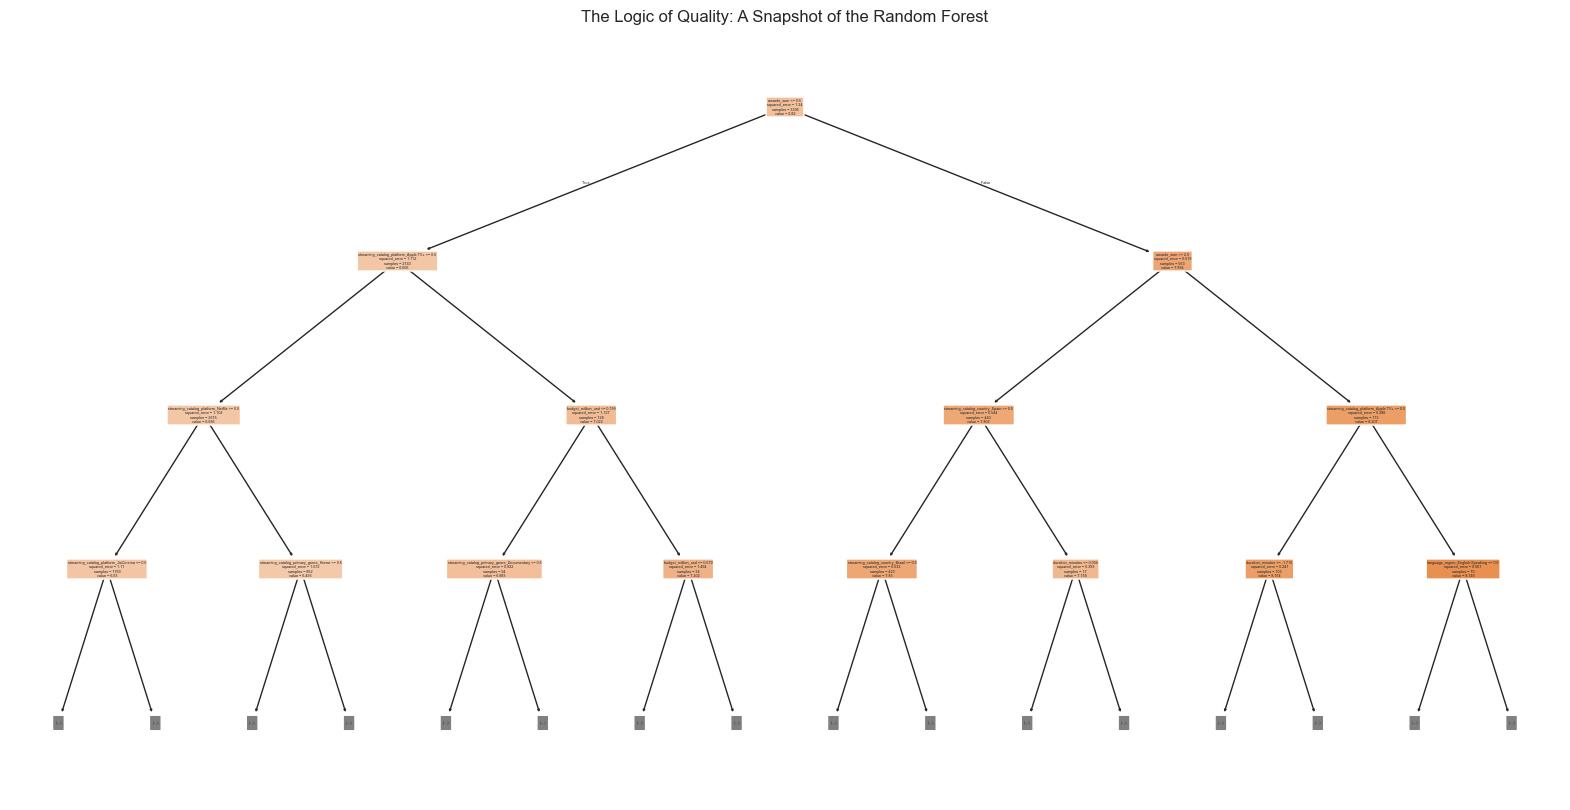


--- Top 10 Features Driving IMDb Ratings ---


,Feature,Importance
2,awards_won,0.786727
1,budget_million_usd,0.059012
0,duration_minutes,0.052102
19,streaming_catalog_platform_Apple TV+,0.017190
22,streaming_catalog_platform_HBO Max,0.010609
11,streaming_catalog_primary_genre_Horror,0.009011
25,streaming_catalog_platform_Netflix,0.004743
9,streaming_catalog_primary_genre_Drama,0.004164
18,streaming_catalog_platform_Amazon Prime Video,0.003502
53,language_region_English Speaking,0.003501


In [63]:
import matplotlib.pyplot as plt

#Train the final winning model
final_model = RandomForestRegressor(n_estimators=100, max_depth=6, min_samples_leaf=5, random_state=42)
final_model.fit(X_train_scaled, y_train_rating)

#Visualize a single decision tree to illustrate model logic
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(final_model.estimators_[0], max_depth=3, feature_names=X_train_scaled.columns, filled=True, rounded=True)
plt.title("The Logic of Quality: A Snapshot of the Random Forest")
plt.show()

#Extract Feature Importance
importances = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': final_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\n--- Top 10 Features Driving IMDb Ratings ---")
display(importances.head(10))

### 3.1.5 Executive Summary - The Hierarchy of Quality

The Random Forest analysis firmly validates our linear regression findings: Perceived Quality (IMDb) is entirely prestige driven

* **The Prestige Absolute (~79%):** 'awards_won' dominates the algorithm. Quality is universally anchored to industry pedigree
* **The Physical Constraints (~11%):** 'budget' and 'duration' follow. Resources are necessary, but cannot buy acclaim alone
* **Genre Irrelevance:** Genres carry almost zero weight, proving that critical success is platform agnostic and genre blind

**Business Takeaway:** To win awards and maximize ratings, platforms must acquire high pedigree content rather than chasing specific genres

### 3.2 Commercial Success - Hours Watched

While linear models failed to capture the chaotic, hit driven nature of streaming viewership, tree based models excel at discovering complex rules

**Methodology: The Same Dataset Validation**
Unlike IMDb ratings (Chapter 3.1) which are bounded on a 1-10 scale, viewership hours follow a steep Power Law distribution with extreme mega hits. In our Linear Regression analysis (Chapter 2), we had to filter out the top 5% of these outliers to achieve any mathematical baseline

To maintain a rigorous, valid comparison against that linear baseline, we must apply the Random Forest strictly to that same Filtered Dataset (the 95%). This ensures that any improvement in our $R^2$ is definitively due to the Random Forest's advanced algorithmic capabilities, and not a byproduct of changing the underlying data structure


In [70]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

#prepare filtered data for Hours Watched (removing top 5% outliers)
threshold = y_train_hours.quantile(0.95)
train_mask = y_train_hours <= threshold
val_mask = y_val_hours <= threshold

X_train_f = X_train_scaled[train_mask]
y_train_f = y_train_hours[train_mask]
X_val_f = X_val_scaled[val_mask]
y_val_f = y_val_hours[val_mask]

#grid depths selected based on insights from the previous chapter
depths = [4, 6, 8, 10, 12]
estimators = [100, 200, 300]

# A specific log for Hours Watched
if 'rf_log_hours' not in globals():
    rf_log_hours = pd.DataFrame(columns=['n_estimators', 'max_depth', 'Train_R2', 'Val_R2', 'Gap', 'Status'])

for depth in depths:
    for n in estimators:
        #Train
        model = RandomForestRegressor(n_estimators=n, max_depth=depth, min_samples_leaf=5, random_state=42)
        model.fit(X_train_f, y_train_f)
        
        #Predict
        train_pred = model.predict(X_train_f)
        val_pred = model.predict(X_val_f)
        
        #Score
        train_r2 = r2_score(y_train_f, train_pred)
        val_r2 = r2_score(y_val_f, val_pred)
        gap = train_r2 - val_r2
        
        #forest Health check
        status = "Healthy" if gap < 0.15 else "Overfitting"
        if train_r2 < 0.05: status = "Underfitting"
            
        #log results
        new_entry = pd.DataFrame({
            'n_estimators': [n], 'max_depth': [depth],
            'Train_R2': [round(train_r2, 4)], 'Val_R2': [round(val_r2, 4)],
            'Gap': [round(gap, 4)], 'Status': [status]
        })
        rf_log_hours = pd.concat([rf_log_hours, new_entry], ignore_index=True)

#clean up duplicate runs
clean_log = rf_log_hours.drop_duplicates()

#display ALL cleaned models to show the full picture
print("--- All Models: Initial Grid Search ---")
display(clean_log.sort_values(by='Val_R2', ascending=False).head(20))

--- All Models: Initial Grid Search ---


,n_estimators,max_depth,Train_R2,Val_R2,Gap,Status
1,200,4,0.0274,0.0002,0.0271,Underfitting
2,300,4,0.0275,0.0001,0.0273,Underfitting
16,200,5,0.0423,-0.0008,0.0431,Underfitting
17,300,5,0.042,-0.0009,0.0429,Underfitting
0,100,4,0.0272,-0.0011,0.0284,Underfitting
4,200,6,0.0596,-0.0019,0.0615,Healthy
5,300,6,0.0592,-0.0019,0.0611,Healthy
15,100,5,0.0426,-0.0023,0.0449,Underfitting
23,300,7,0.0797,-0.0031,0.0827,Healthy
22,200,7,0.0801,-0.0036,0.0837,Healthy


**Insight:** The preliminary scan highlights depths 6-8 as stable boundaries

### 3.2.2 In Depth Grid
To ensure we don't miss the absolute mathematical peak, we will conduct a granular, continuous search across the entire 5-9 depth range

In [71]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

#focused grid search on the granular 5-9 zone
depths = [5, 6, 7, 8, 9]
estimators = [100, 200, 300]

print("--- Searching the 5-9 Zone ---")

for depth in depths:
    for n in estimators:
        #utilizing min_samples_leaf to prevent noise in highly volatile viewership data
        model = RandomForestRegressor(n_estimators=n, max_depth=depth, min_samples_leaf=5, random_state=42)
        model.fit(X_train_f, y_train_f)
        
        #Predict
        train_pred = model.predict(X_train_f)
        val_pred = model.predict(X_val_f)
        
        #Score
        train_r2 = r2_score(y_train_f, train_pred)
        val_r2 = r2_score(y_val_f, val_pred)
        gap = train_r2 - val_r2
        
        #Health check logic
        status = "Healthy" if gap < 0.15 else "Overfitting"
        if train_r2 < 0.05: status = "Underfitting"
            
        #log results
        new_entry = pd.DataFrame({
            'n_estimators': [n], 'max_depth': [depth],
            'Train_R2': [round(train_r2, 4)], 'Val_R2': [round(val_r2, 4)],
            'Gap': [round(gap, 4)], 'Status': [status]
        })
        rf_log_hours = pd.concat([rf_log_hours, new_entry], ignore_index=True)

#clean duplicates and explicitly display the top 20 models across all statuses
clean_log_hours = rf_log_hours.drop_duplicates()

print("--- All Models: Granular Search (Depths 5-9) ---")
display(clean_log_hours.sort_values(by='Val_R2', ascending=False).head(20))

--- Searching the 5-9 Zone ---
--- All Models: Granular Search (Depths 5-9) ---


,n_estimators,max_depth,Train_R2,Val_R2,Gap,Status
1,200,4,0.0274,0.0002,0.0271,Underfitting
2,300,4,0.0275,0.0001,0.0273,Underfitting
16,200,5,0.0423,-0.0008,0.0431,Underfitting
17,300,5,0.042,-0.0009,0.0429,Underfitting
0,100,4,0.0272,-0.0011,0.0284,Underfitting
4,200,6,0.0596,-0.0019,0.0615,Healthy
5,300,6,0.0592,-0.0019,0.0611,Healthy
15,100,5,0.0426,-0.0023,0.0449,Underfitting
23,300,7,0.0797,-0.0031,0.0827,Healthy
22,200,7,0.0801,-0.0036,0.0837,Healthy


**Insight:** Even after a granular search across the optimal depth range (5-9), the highest validation $R^2$ remains negative. This confirms a structural reality of our dataset: predicting raw viewership hours is mathematically unfeasible due to extreme right skewed variance


### 3.2.3 Squashing the Skew - Log Transformation

To resolve the problem, we apply a Log Transformation('np.log1p'). By mathematically compressing the massive scale differences between standard content and viral hits, we allow the algorithm to focus on learning relative proportional relationships rather than chasing absolute viewership millions

In [69]:
import numpy as np

#create og transformed target
#use np.log1p (log(x+1)) to safely handle any potential 0 hour values
y_train_log = np.log1p(y_train_f)
y_val_log = np.log1p(y_val_f)

print("--- Running Log-Transformed Random Forest ---")

#optimal range scan on transformed data
depths = [5, 6, 7, 8, 9]
estimators = [100, 200, 300]

#dedicated log for transformed models
rf_log_hours_transformed = pd.DataFrame(columns=['n_estimators', 'max_depth', 'Train_R2', 'Val_R2', 'Gap', 'Status'])

for depth in depths:
    for n in estimators:
        #mdel being trained on log Hours
        model = RandomForestRegressor(n_estimators=n, max_depth=depth, min_samples_leaf=5, random_state=42)
        model.fit(X_train_f, y_train_log)
        
        #Predict
        train_pred_log = model.predict(X_train_f)
        val_pred_log = model.predict(X_val_f)
        
        #Score is calculated in logspace
        train_r2 = r2_score(y_train_log, train_pred_log)
        val_r2 = r2_score(y_val_log, val_pred_log)
        
        gap = train_r2 - val_r2
        status = "Healthy" if gap < 0.15 else "Overfitting"
        
        #log results
        new_entry = pd.DataFrame({
            'n_estimators': [n], 'max_depth': [depth],
            'Train_R2': [round(train_r2, 4)], 'Val_R2': [round(val_r2, 4)],
            'Gap': [round(gap, 4)], 'Status': [status]
        })
        rf_log_hours_transformed = pd.concat([rf_log_hours_transformed, new_entry], ignore_index=True)


#Clean duplicates and explicitly display the top healthy models
clean_log_transformed = rf_log_hours_transformed.drop_duplicates()
healthy_transformed = clean_log_transformed[clean_log_transformed['Status'] == 'Healthy']

print("--- Top 'Healthy' Log-Transformed Models ---")
display(healthy_transformed.sort_values(by='Val_R2', ascending=False).head(15))

--- Running Log-Transformed Random Forest ---
--- Top 'Healthy' Log-Transformed Models ---


,n_estimators,max_depth,Train_R2,Val_R2,Gap,Status
2,300,5,0.0335,-0.0014,0.0349,Healthy
1,200,5,0.0334,-0.0019,0.0353,Healthy
0,100,5,0.0325,-0.0025,0.035,Healthy
5,300,6,0.0488,-0.0025,0.0513,Healthy
3,100,6,0.0474,-0.0033,0.0507,Healthy
4,200,6,0.0488,-0.0036,0.0523,Healthy
8,300,7,0.0668,-0.0043,0.071,Healthy
6,100,7,0.065,-0.0053,0.0703,Healthy
7,200,7,0.0669,-0.0055,0.0724,Healthy
11,300,8,0.0868,-0.0058,0.0926,Healthy


**Insight:** Even with Log Transformation, the $R^2$ remains structurally weak. This is a crucial finding: Predicting exact viewership numbers using standard metadata is statistically impossible. Audience traffic is chaotic. Therefore, we must pivot


### 3.2.4 Strategic Gap Analysis: From Prediction to Growth

Instead of predicting individual movie performance, we will use the Random Forest's "Feature Importance" to identify Market Gaps - high demand segments where our current catalog is underserved

**The Opportunity Formula:**
$$\text{Opportunity Score} = \text{Demand (Feature Importance)} \times \text{Low Supply (Catalog Deficit)}$$

By cross-referencing what drives traffic with what we actually own, we transform this model into a strategic roadmap for studio executives to maximize ROI and reduce acquisition risk

In [72]:
#train the model specifically to extract what moves the needle in viewership
rf_hours = RandomForestRegressor(n_estimators=300, max_depth=8, min_samples_leaf=5, random_state=42)
rf_hours.fit(X_train_f, y_train_f)

#Extract feature importance
importances = pd.DataFrame({
    'Feature': X_train_f.columns,
    'Importance': rf_hours.feature_importances_
}).sort_values(by='Importance', ascending=False)

#display Top 15 drivers of traffic
print("--- Features Driving Commercial Success (Hours Watched) ---")
display(importances.head(15))

--- Features Driving Commercial Success (Hours Watched) ---


,Feature,Importance
1,budget_million_usd,0.303458
0,duration_minutes,0.270514
2,awards_won,0.042511
53,language_region_English Speaking,0.024840
27,streaming_catalog_platform_Peacock,0.020456
51,streaming_catalog_country_United States,0.020024
6,streaming_catalog_primary_genre_Comedy,0.019432
25,streaming_catalog_platform_Netflix,0.018831
9,streaming_catalog_primary_genre_Drama,0.014872
3,streaming_catalog_primary_genre_Action,0.014714


### Defining the Strategic Levers

Our model reveals a clear divide in commercial drivers:
1. **Production Constraints (~57%):** 'Budget and 'Duration' heavily dictate success, but they are expensive constraints, not flexible tactics
2. **Strategic Levers:** Features like 'Country: Turkey', 'Platform: Peacock', and 'Genre: Comedy/Action' hold significant weight

### 3.2.5 Findings in the Actual Data
To find our "Golden Gaps", we isolate these strategic levers and audit our current catalog to see if we are successfully supplying this audience demand

In [73]:
import pandas as pd

#select the strategic features, excluding Budget and Duration
strategic_features = ['streaming_catalog_primary_genre_Comedy', 'streaming_catalog_country_Turkey', 'streaming_catalog_primary_genre_Action','streaming_catalog_platform_Peacock']

#calculate the actual presence of these features in our catalog using our training data
gap_audit = pd.DataFrame({
    'Presence_Count': [X_train_f[f].sum() for f in strategic_features],
    'Percentage': [X_train_f[f].mean() * 100 for f in strategic_features]
}, index=strategic_features)

display(gap_audit.sort_values(by='Percentage', ascending=True))

,Presence_Count,Percentage
streaming_catalog_country_Turkey,99,1.995565
streaming_catalog_platform_Peacock,147,2.963112
streaming_catalog_primary_genre_Action,620,12.497480
streaming_catalog_primary_genre_Comedy,669,13.485184


### 3.2.6 The Golden Gaps: Audit Results & Strategic Recommendations

By cross referencing the Random Forest Feature Importances with our catalog's actual inventory, we extract our final strategic insights:

| Strategic Feature | Importance Rank | Catalog Presence | Strategic Status |
| :--- | :--- | :--- | :--- |
| **Country: Turkey** | Top 15 Driver | 1.99% | 🚨 Critical Gap (Blue Ocean) |
| **Platform: Peacock** | Top 15 Driver | 2.96% | 🚨 Critical Gap (Under-leveraged) |
| **Genre: Action** | Top 15 Driver | 12.49% | ✅ Core Staple (Maintain) |
| **Genre: Comedy** | Top 15 Driver | 13.48% | ✅ Core Staple (Maintain) |


* **The Insight:** Viewership is heavily influenced by specific regional and platform levers, notably Turkish content and Peacock releases. However, our audit reveals these categories make up less than 3% of our current catalog.
* **The Strategic Action:** Divert production and acquisition budgets toward Turkish co-productions and Peacock licensing. These are high-demand, low-supply "Blue Oceans" that will yield the highest commercial ROI. Maintain Action/Comedy (13% presence) merely as baseline filler


## 3.4 Executive Summary: The Content Strategy

By applying Random Forest models to both critical and commercial metrics, we dictate a clear, two-pronged business strategy for the studio:

1. **For Prestige (High IMDb):** Buy Pedigree. Prioritize the acquisition of award-winning titles over any specific genre or language
2. **For Profit (High Viewership):** Exploit the Gaps. Stop over investing in saturated generic content (like standard American Action movies) and pivot aggressively to high demand, under supplied segments like the Turkish market

# 4. Final Conclusions & Strategic Recommendations

This project set out to decode the streaming industry's dual mandate: achieving critical acclaim (IMDb Ratings) and driving commercial scale (Hours Watched). By progressing from baseline Linear Regression models to advanced Random Forest algorithms, we discovered that quality and traffic are driven by entirely different mechanisms

To thrive in the competitive streaming landscape, studios must adopt a bifurcated strategy

### 4.1 The Quality Paradox: The Limits of Formulaic Production
Our modeling initially highlighted awards_won as the absolute dominant predictor (79% influence) of a movie's IMDb rating. However, from a business perspective, this presents a classic correlation vs. causation dilemma

**The Insight:** The data reveals a strong mutual connection between audience appreciation (high IMDb scores) and critics' validation (awards won) - essentially, successful movies win awards, and award-winning movies are highly rated. However, we cannot definitively conclude which causes which. What the data does prove is that standard metadata - genre, country of origin, and language - has almost zero predictive power over this perceived quality

**Strategic Action:** Because high IMDb ratings are a byproduct of artistic execution rather than a mix of physical attributes, studios cannot engineer a prestige movie by simply combining specific genres or platforms. Therefore, from a financial standpoint, studios should not allocate massive production budgets chasing critical acclaim through data formulas. Instead, capital should be aggressively redirected toward commercial metrics (Hours Watched), where data driven gaps can actually guarantee scalable ROI

### 4.2 Exploiting Market Gaps

Predicting exact viewership numbers proved mathematically unfeasible due to the chaotic, "power law" distribution of viral hits. However, transitioning our machine learning model into a Strategic Gap Analysis uncovered clear market opportunities

* **The Insight:** While baseline traffic is driven by sheer production scale (budget/duration), disproportionate growth comes from specific, underserved "Blue Ocean" segments
* **Strategic Action:** Our audit revealed that Turkish content and Peacock releases are major drivers of audience viewership, yet they account for less than 3% of the current catalog combined. Studios must aggressively divert production and licensing budgets to these specific, high ROI market gaps where audience hunger outstrips supply

### 4.3 Executive Suggestions

To maximize financial efficiency and market ROI, the studio must implement the following data driven operational changes:

1. **Stop Engineering Prestige:** Acknowledge that critical acclaim (IMDb ratings) cannot be formulated through specific genres, locations, or high production costs. Cease over-allocating capital to generic "award-bait" projects, as the data proves these attributes do not guarantee quality
2. **Exploit the Golden Gaps:** Pivot commercial acquisition and production investments directly into the Turkish market and the Peacock platform. These represent highly engaged, underserved audiences (currently less than 3% of supply) where capital will yield the highest return on investment
3. **Cap the Core:** Treat traditional combinations, like American Action and Comedy genres (~13% of the catalog), as stable foundational assets. Maintain their current inventory levels to satisfy baseline demand, but restrict aggressive budget increases, as they are heavily saturated and not the primary engines for disproportionate growth